# Re-ID Robustness Check on ECG-ID

This notebook serves as a robustness check for the main paper's Re-ID
results. We rerun the same DP sweep on a second, independent database
(ECG-ID, PhysioNet ecgiddb/1.0.0) and check whether the privacy-utility
trade-off looks similar.

**Methodological note:** ECG-ID is sampled at 500 Hz vs MIT-BIH's 360 Hz.
Consecutive samples are closer in time, so the absolute jump |x_{i+1} - x_i|
tends to be smaller. Our sensitivity Delta = 0.29 is calibrated on MIT-BIH;
applying the same value to ECG-ID is slightly conservative (a bit more
noise than strictly required). This is acceptable for a robustness check
and should be acknowledged in the paper's Methods section.

ECG-ID has 90 subjects with session-based train/test split, which is a
considerably harder Re-ID benchmark than MIT-BIH's 22 patients with an
intra-record temporal split. We expect:
  * Random baseline = 1/90 ~ 0.011 (vs MIT-BIH's 1/22 ~ 0.045).
  * Lower clean-baseline Re-ID accuracy (harder task).
  * Same qualitative trade-off curve shape.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _loader import (
    load_utility_baseline, load_utility_sweep,
    load_reid_baseline, load_reid_sweep,
)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300,
    'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'savefig.bbox': 'tight', 'figure.constrained_layout.use': False,
})

RESULTS = Path('../results')
FIGURES = Path('../results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

MECH_LABELS = {
    'laplace': 'Laplace',
    'laplace_bounded': 'Bounded Laplace',
    'gaussian_analytic': 'Analytic Gaussian',
}
MECH_MARKERS = {
    'laplace': 'o',
    'laplace_bounded': 's',
    'gaussian_analytic': '^',
}
THREAT_MODEL = 'adaptive_attacker'

## Load utility and ECG-ID Re-ID results

In [2]:
util_baseline = load_utility_baseline(RESULTS)
util_sweep = load_utility_sweep(RESULTS)
reid_mit_baseline = load_reid_baseline(RESULTS / 'reid')
reid_mit_sweep = load_reid_sweep(RESULTS / 'reid')
reid_ecg_baseline = load_reid_baseline(RESULTS / 'reid_ecgid')
reid_ecg_sweep = load_reid_sweep(RESULTS / 'reid_ecgid')

print(f'Utility sweep rows:       {len(util_sweep)}')
print(f'MIT-BIH Re-ID rows:       {len(reid_mit_sweep)}')
print(f'ECG-ID Re-ID rows:        {len(reid_ecg_sweep)}')
print()

util_baseline_macro = util_baseline['macro_f1'].mean() if not util_baseline.empty else np.nan
reid_mit_clean = reid_mit_baseline['reid_accuracy'].mean() if not reid_mit_baseline.empty else np.nan
reid_ecg_clean = reid_ecg_baseline['reid_accuracy'].mean() if not reid_ecg_baseline.empty else np.nan
reid_mit_random = reid_mit_baseline['random_baseline'].iloc[0] if not reid_mit_baseline.empty else np.nan
reid_ecg_random = reid_ecg_baseline['random_baseline'].iloc[0] if not reid_ecg_baseline.empty else np.nan
n_subjects_mit = reid_mit_baseline['n_subjects'].iloc[0] if not reid_mit_baseline.empty else np.nan
n_subjects_ecg = reid_ecg_baseline['n_subjects'].iloc[0] if not reid_ecg_baseline.empty else np.nan

print(f'Utility baseline F1:           {util_baseline_macro:.4f}')
print(f'MIT-BIH Re-ID baseline:        {reid_mit_clean:.4f}  ({int(n_subjects_mit)} subjects, random {reid_mit_random:.4f})')
print(f'ECG-ID Re-ID baseline:         {reid_ecg_clean:.4f}  ({int(n_subjects_ecg)} subjects, random {reid_ecg_random:.4f})')

Utility sweep rows:       162
MIT-BIH Re-ID rows:       525
ECG-ID Re-ID rows:        525

Utility baseline F1:           0.9501
MIT-BIH Re-ID baseline:        0.9872  (22 subjects, random 0.0455)
ECG-ID Re-ID baseline:         0.4856  (89 subjects, random 0.0112)


In [3]:
# Aggregate Re-ID over seeds, both datasets
def agg_reid(df):
    return (
        df[df['threat_model'] == THREAT_MODEL]
        .groupby(['mechanism', 'eps', 'delta'])
        ['reid_accuracy'].agg(['mean', 'std']).reset_index()
        .rename(columns={'mean': 'reid_mean', 'std': 'reid_std'})
    )

reid_mit_agg = agg_reid(reid_mit_sweep)
reid_ecg_agg = agg_reid(reid_ecg_sweep)
util_agg = (
    util_sweep.groupby(['mechanism', 'eps', 'delta'])
    ['macro_f1'].agg(['mean', 'std']).reset_index()
    .rename(columns={'mean': 'util_mean', 'std': 'util_std'})
)

print(f'ECG-ID aggregated configs: {len(reid_ecg_agg)}')
reid_ecg_agg.head(8).round(3)

ECG-ID aggregated configs: 54


,mechanism,eps,delta,reid_mean,reid_std
0,gaussian_analytic,0.050,0.0,0.065,0.000
1,gaussian_analytic,0.100,0.0,0.066,0.002
2,gaussian_analytic,0.150,0.0,0.065,0.000
3,gaussian_analytic,0.175,0.0,0.068,0.005
4,gaussian_analytic,0.200,0.0,0.067,0.002
5,gaussian_analytic,0.225,0.0,0.072,0.003
6,gaussian_analytic,0.250,0.0,0.077,0.010
7,gaussian_analytic,0.300,0.0,0.090,0.009


## Side-by-side comparison: MIT-BIH vs ECG-ID Re-ID curves

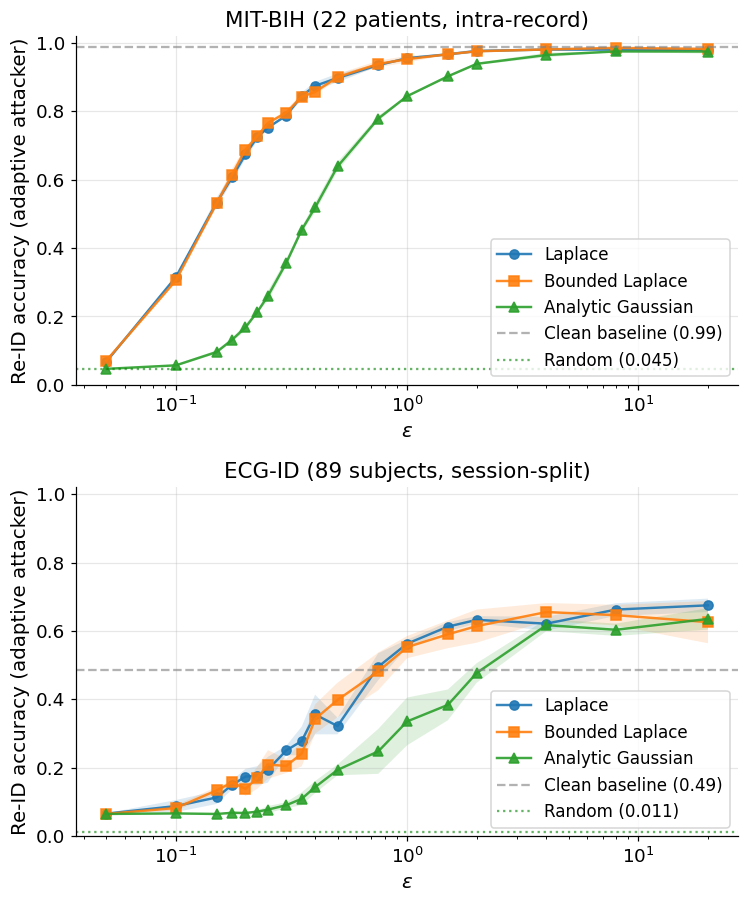

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(7.0, 8.4), sharey=False)

for ax, agg_df, ds_label, clean_acc, random_acc, n_subj in zip(
    axes,
    [reid_mit_agg, reid_ecg_agg],
    ['MIT-BIH (22 patients, intra-record)', f'ECG-ID ({int(n_subjects_ecg)} subjects, session-split)'],
    [reid_mit_clean, reid_ecg_clean],
    [reid_mit_random, reid_ecg_random],
    [n_subjects_mit, n_subjects_ecg],
):
    if agg_df.empty:
        ax.set_title(f'{ds_label} (no data)')
        continue
    for mech in MECH_LABELS:
        sub = agg_df[agg_df['mechanism'] == mech].sort_values('eps')
        if sub.empty:
            continue
        ax.plot(sub['eps'], sub['reid_mean'], marker=MECH_MARKERS[mech],
                linestyle='-', markersize=6, linewidth=1.6,
                label=MECH_LABELS[mech], alpha=0.9)
        ax.fill_between(sub['eps'],
                         sub['reid_mean'] - sub['reid_std'].fillna(0),
                         sub['reid_mean'] + sub['reid_std'].fillna(0),
                         alpha=0.15)
    if not np.isnan(clean_acc):
        ax.axhline(clean_acc, color='gray', linestyle='--', alpha=0.6,
                   label=f'Clean baseline ({clean_acc:.2f})')
    if not np.isnan(random_acc):
        ax.axhline(random_acc, color='green', linestyle=':', alpha=0.6,
                   label=f'Random ({random_acc:.3f})')
    ax.set_xscale('log')
    ax.set_xlabel(r'$\varepsilon$')
    ax.set_ylabel('Re-ID accuracy (adaptive attacker)')
    ax.set_title(ds_label)
    ax.legend(loc='lower right', fontsize=11)
    ax.set_ylim(0, 1.02)

#fig.suptitle('Re-identification under privacy: within-recording versus cross-session', y=1.005, fontsize=15)
fig.tight_layout()
fig.savefig(FIGURES / 'reid_robustness_mitbih_vs_ecgid.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'reid_robustness_mitbih_vs_ecgid.png', bbox_inches='tight')
plt.show()

## Money figure on ECG-ID (combining utility from MIT-BIH with Re-ID from ECG-ID)

Strictly speaking the utility classifier is trained on MIT-BIH (since ECG-ID
has no arrhythmia annotations). So this figure asks: at any given eps, what
would the trade-off look like if we measured re-identifiability on a
different, harder dataset? This is a stronger statement: if Re-ID is hard on
ECG-ID then patient-level privacy is robust beyond just MIT-BIH.

Merged configs (utility MIT-BIH + reid ECG-ID): 54


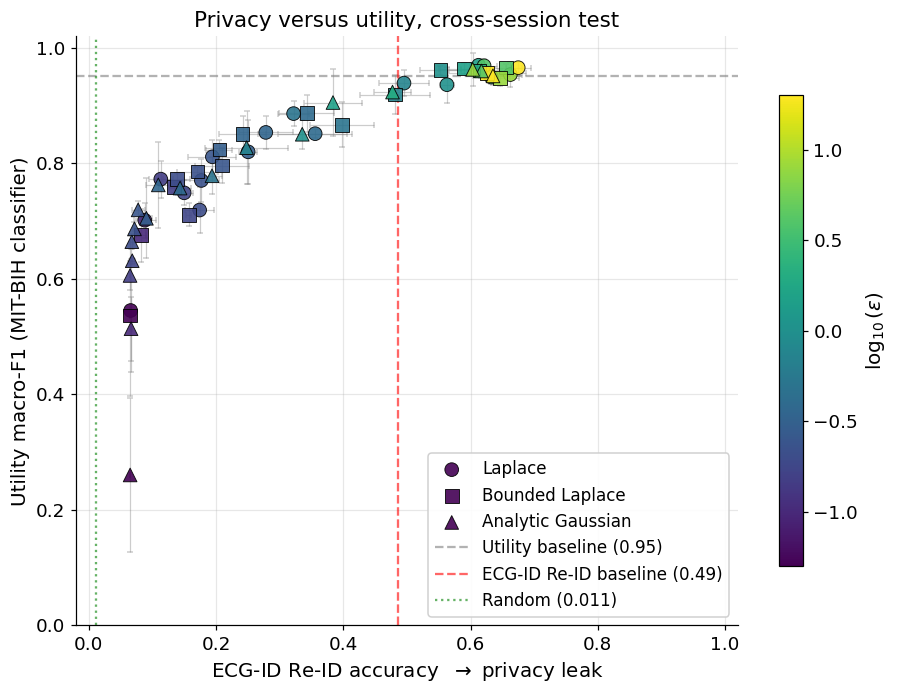

In [5]:
merged_ecg = util_agg.merge(reid_ecg_agg, on=['mechanism', 'eps', 'delta'], how='inner')
print(f'Merged configs (utility MIT-BIH + reid ECG-ID): {len(merged_ecg)}')

if not merged_ecg.empty:
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    eps_values = sorted(merged_ecg['eps'].unique())
    log_eps_all = np.log10(np.array(eps_values))
    norm = plt.Normalize(vmin=log_eps_all.min(), vmax=log_eps_all.max())
    cmap = plt.cm.viridis

    for mech in MECH_LABELS:
        sub = merged_ecg[merged_ecg['mechanism'] == mech]
        if sub.empty:
            continue
        colors = cmap(norm(np.log10(sub['eps'].values)))
        for _, row in sub.iterrows():
            ax.errorbar(
                row['reid_mean'], row['util_mean'],
                xerr=row['reid_std'] if not np.isnan(row['reid_std']) else 0,
                yerr=row['util_std'] if not np.isnan(row['util_std']) else 0,
                fmt='none', ecolor='gray', alpha=0.4, capsize=2, linewidth=0.8, zorder=2,
            )
        ax.scatter(
            sub['reid_mean'], sub['util_mean'],
            c=colors, marker=MECH_MARKERS[mech], s=80, alpha=0.9,
            edgecolors='black', linewidth=0.6, zorder=3,
            label=MECH_LABELS[mech],
        )

    if not np.isnan(util_baseline_macro):
        ax.axhline(util_baseline_macro, color='gray', linestyle='--', alpha=0.6,
                   label=f'Utility baseline ({util_baseline_macro:.2f})')
    if not np.isnan(reid_ecg_clean):
        ax.axvline(reid_ecg_clean, color='red', linestyle='--', alpha=0.6,
                   label=f'ECG-ID Re-ID baseline ({reid_ecg_clean:.2f})')
    if not np.isnan(reid_ecg_random):
        ax.axvline(reid_ecg_random, color='green', linestyle=':', alpha=0.6,
                   label=f'Random ({reid_ecg_random:.3f})')
    ax.set_xlabel(r'ECG-ID Re-ID accuracy  $\rightarrow$ privacy leak')
    ax.set_ylabel('Utility macro-F1 (MIT-BIH classifier)')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 1.02)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, ax=ax, label=r'$\log_{10}(\varepsilon)$', shrink=0.8)
    ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
    ax.set_title('Privacy versus utility, cross-session test')
    fig.tight_layout()
    fig.savefig(FIGURES / 'money_figure_ecgid.pdf', bbox_inches='tight')
    fig.savefig(FIGURES / 'money_figure_ecgid.png', bbox_inches='tight')
    plt.show()

## Direct comparison: Re-ID accuracy MIT-BIH vs ECG-ID at each epsilon

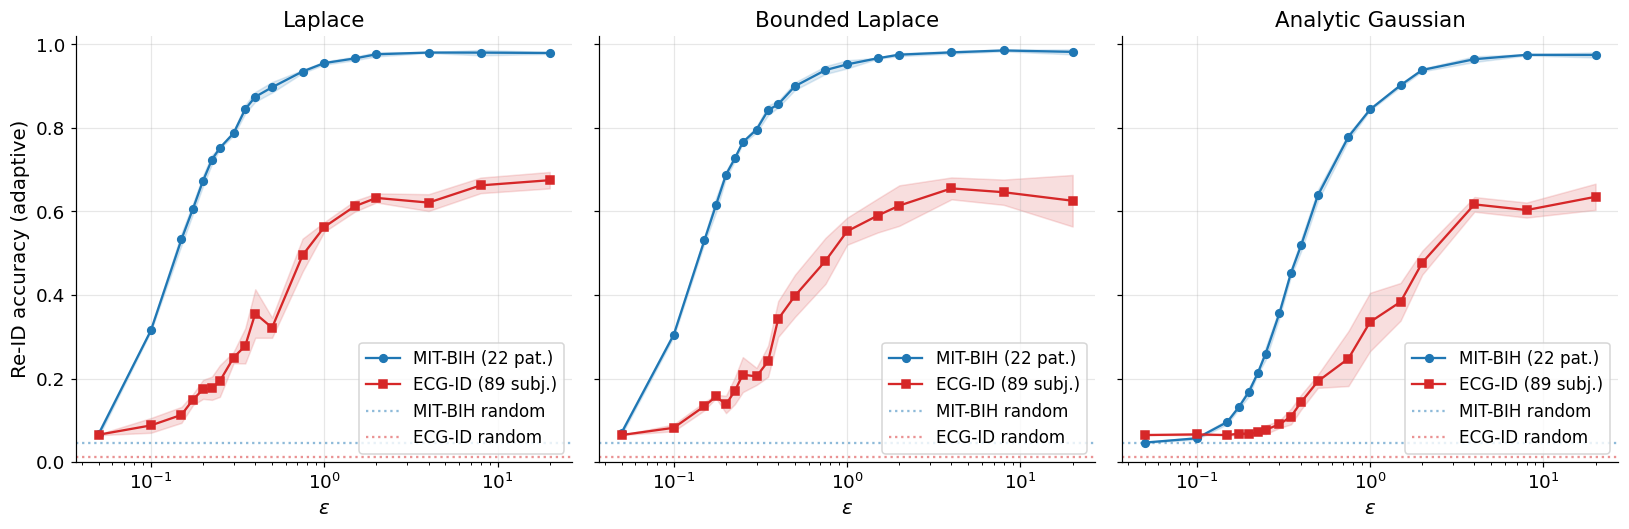

In [6]:
# Compare laplace mechanism across both datasets
fig, axes = plt.subplots(1, 3, figsize=(15, 5.0), sharey=True)
for ax, mech in zip(axes, MECH_LABELS):
    mit = reid_mit_agg[reid_mit_agg['mechanism'] == mech].sort_values('eps')
    ecg = reid_ecg_agg[reid_ecg_agg['mechanism'] == mech].sort_values('eps')
    if not mit.empty:
        ax.plot(mit['eps'], mit['reid_mean'], 'o-', color='#1f77b4',
                markersize=5, label=f'MIT-BIH ({int(n_subjects_mit)} pat.)')
        ax.fill_between(mit['eps'],
                         mit['reid_mean'] - mit['reid_std'].fillna(0),
                         mit['reid_mean'] + mit['reid_std'].fillna(0),
                         alpha=0.15, color='#1f77b4')
    if not ecg.empty:
        ax.plot(ecg['eps'], ecg['reid_mean'], 's-', color='#d62728',
                markersize=5, label=f'ECG-ID ({int(n_subjects_ecg)} subj.)')
        ax.fill_between(ecg['eps'],
                         ecg['reid_mean'] - ecg['reid_std'].fillna(0),
                         ecg['reid_mean'] + ecg['reid_std'].fillna(0),
                         alpha=0.15, color='#d62728')
    if not np.isnan(reid_mit_random):
        ax.axhline(reid_mit_random, color='#1f77b4', linestyle=':', alpha=0.5,
                   label=f'MIT-BIH random')
    if not np.isnan(reid_ecg_random):
        ax.axhline(reid_ecg_random, color='#d62728', linestyle=':', alpha=0.5,
                   label=f'ECG-ID random')
    ax.set_xscale('log')
    ax.set_xlabel(r'$\varepsilon$')
    ax.set_title(MECH_LABELS[mech])
    ax.legend(loc='lower right', fontsize=11)
    ax.set_ylim(0, 1.02)

axes[0].set_ylabel('Re-ID accuracy (adaptive)')
#fig.suptitle('Re-identification by mechanism: within-recording versus cross-session', y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(FIGURES / 'reid_comparison_per_mechanism.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'reid_comparison_per_mechanism.png', bbox_inches='tight')
plt.show()

## Summary table

In [7]:
if not reid_ecg_agg.empty:
    summary_ecg = util_agg.merge(reid_ecg_agg, on=['mechanism', 'eps', 'delta'], how='inner')
    summary_ecg['joint_score'] = summary_ecg['util_mean'] - summary_ecg['reid_mean']
    summary_ecg.to_csv(RESULTS / 'privacy_utility_summary_ecgid.csv', index=False)
    print(f'Saved: {RESULTS / "privacy_utility_summary_ecgid.csv"}')
    print()
    print('Best joint score per mechanism (ECG-ID Re-ID):')
    for mech in MECH_LABELS:
        sub = summary_ecg[summary_ecg['mechanism'] == mech]
        if sub.empty:
            continue
        best = sub.loc[sub['joint_score'].idxmax()]
        print(f"  {mech:<20s}: eps={best['eps']:>6.3g}, joint={best['joint_score']:+.3f} "
              f"(util={best['util_mean']:.3f}+-{best['util_std']:.3f}, "
              f"reid={best['reid_mean']:.3f}+-{best['reid_std']:.3f})")
else:
    print('No ECG-ID Re-ID results found; run the sweep first.')

Saved: ../results/privacy_utility_summary_ecgid.csv

Best joint score per mechanism (ECG-ID Re-ID):
  laplace             : eps=  0.15, joint=+0.659 (util=0.772+-0.032, reid=0.113+-0.019)
  laplace_bounded     : eps=   0.2, joint=+0.635 (util=0.773+-0.011, reid=0.138+-0.021)
  gaussian_analytic   : eps=  0.35, joint=+0.653 (util=0.762+-0.074, reid=0.109+-0.019)
